In [11]:
#added slippage stress test= slippage factor

In [62]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

df = yf.download("AMZN", start="2005-01-01", auto_adjust=True)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

breakout = 20
atr_mult = 3.5

[*********************100%***********************]  1 of 1 completed


In [66]:
#Series definitions

def run_backtest(df, breakout, atr_mult, slip_factor = 1.0):
    df = df.copy()
    
    df['breakout_high'] = df['High'].shift(1).rolling(breakout).max()
    df['breakout_low'] = df['Low'].shift(1).rolling(breakout).min()
    df['sma200'] = df['Close'].rolling(200).mean()
    df['returns_std'] = df['Close'].pct_change(fill_method=None).rolling(breakout).std()
    df['true_range'] = np.maximum(
        df['High'] - df['Low'],
        np.maximum(
            abs(df['High'] - df['Close'].shift(1)),
            abs(df['Low'] - df['Close'].shift(1))
        )
    )
    df['atr'] = df['true_range'].rolling(14).mean()
    df['returns_std_ma'] = df['returns_std'].rolling(100).mean()
    
    capital = 100000
    cash = capital
    cost = 0.001
    position = 0
    entry_price = 0
    highest_price = None

    position_size = 0.7     #(locked after trying multiple vallues from 0.5-1)
    
    equity = []
    
    trades = []
    
    entry_idx = None
    
    position_history = []
    
    
    for i in range(len(df)):

        close = df['Close'].iloc[i]
        
        if i == len(df) - 1:
            equity.append(cash + position * close)
            position_history.append(1 if position > 0 else 0)
            break
            
        next_open = df['Open'].iloc[i+1]
        
        breakout_high = df['breakout_high'].iloc[i]
        breakout_low  = df['breakout_low'].iloc[i]
        sma = df['sma200'].iloc[i]
        returns_std = df['returns_std'].iloc[i]
        returns_std_ma = df['returns_std_ma'].iloc[i]
        atr = df['atr'].iloc[i]
        slippage = (0.1 * atr / close) * slip_factor #fixed one was 0.0005

        
        #NaN handling correction final
        if any(pd.isna(x) for x in [breakout_high, breakout_low, sma, returns_std, returns_std_ma, atr]):
            equity.append(cash + position * close)
            position_history.append(1 if position > 0 else 0)
            continue

            
        # ---------------- ENTRY ----------------
        if position == 0:
    
            if close > breakout_high:
    
                entry_price = next_open * (1 + cost/2 + slippage)
                shares = (cash * position_size) / entry_price
                
                position = shares
                cash -= shares * entry_price
                
                highest_price = close
                entry_idx = i # Real cash deduction model 
    
        # ---------------- EXIT ----------------
        elif position > 0:
            
            
            if highest_price is None:
                highest_price = close
            else:
                highest_price = max(highest_price, close)
            
            atr_stop = highest_price - atr_mult * atr
            donchian_stop = breakout_low
            
            exit_level = max(donchian_stop, atr_stop)
    
            
            # ATR-based exit (replace low20 exit)
            if close <  exit_level:
                exit_price = next_open * (1 - cost/2 - slippage)
               
                pnl = (exit_price - entry_price) / entry_price
                duration = i - entry_idx
                trades.append((pnl, duration)) 
    
                cash += position * exit_price
                position = 0
                entry_price = 0
                entry_idx = None
                highest_price = None
    
        # ---------------- EQUITY ----------------
        equity.append(cash + position * close)
        position_history.append(1 if position > 0 else 0)
    
    
    
        # ================= METRICS =================
    
    equity = pd.Series(equity, index=df.index)
    
    # --- Returns ---
    
    returns = equity.pct_change()
    
    # --- CAGR (time-based) ---
    years = (df.index[-1] - df.index[0]).days / 365.25
    
    if years > 0:
        cagr = (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1
    else:
        cagr = np.nan
    
    # --- Vol / Sharpe ---
    if returns.std() > 0:
        vol_ann = returns.std() * np.sqrt(252)
        sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
    else:
        vol_ann = sharpe = np.nan
        
    # --- Sortino ---
    downside = returns[returns < 0]
    sortino = (returns.mean() / downside.std()) * np.sqrt(252) if downside.std() > 0 else np.nan

    downside = returns[returns < 0]

    if len(downside) > 0 and downside.std() > 0:
        sortino = (returns.mean() / downside.std()) * np.sqrt(252)
    else:
        sortino = np.nan
        
    # --- Drawdowns ---
    cum_max = equity.cummax()
    drawdown = equity / cum_max - 1
    
    max_dd = drawdown.min()
    avg_dd = drawdown[drawdown < 0].mean()
    
    # --- Drawdown Duration ---
    dd_flag = (drawdown < 0).astype(int)
    
    dd_duration = (
        dd_flag.groupby((dd_flag != dd_flag.shift()).cumsum())
        .cumsum()
    )
    
    max_dd_duration = dd_duration.max()
    avg_dd_duration = dd_duration[dd_duration > 0].mean()
    
    # --- Trade Stats ---
    if len(trades) > 0:
        trade_returns = np.array([t[0] for t in trades])
        trade_durations = np.array([t[1] for t in trades])
    
        win_rate = (trade_returns > 0).mean()
    
        wins = trade_returns[trade_returns > 0]
        losses = trade_returns[trade_returns < 0]
    
        profit_factor = (
            wins.sum() / abs(losses.sum())
            if len(losses) > 0 else np.nan
        )
    
        expectancy = trade_returns.mean()
        best_trade = trade_returns.max()
        worst_trade = trade_returns.min()
    
        max_trade_duration = trade_durations.max()
        avg_trade_duration = trade_durations.mean()
    
        # --- SQN ---
        if len(trade_returns) > 1 and trade_returns.std() > 0:
            sqn = (trade_returns.mean() / trade_returns.std()) * np.sqrt(len(trade_returns))
        else:
            sqn = np.nan
    
        # --- Kelly ---
        if len(wins) > 0 and len(losses) > 0:
            kelly = win_rate - (1 - win_rate) / (wins.mean() / abs(losses.mean()))
        else:
            kelly = np.nan
    
    else:
        win_rate = profit_factor = expectancy = np.nan
        best_trade = worst_trade = np.nan
        max_trade_duration = avg_trade_duration = sqn = kelly = np.nan
    
    # --- Exposure ---
    exposure = np.mean(position_history)
    
    # --- Buy & Hold ---
    buy_hold = df['Close'].iloc[-1] / df['Close'].iloc[0] - 1
    
    # ================= PRINT =================
    

    return {
        "cagr": cagr,
        "sharpe": sharpe,
        "sortino": sortino,
        "vol_ann": vol_ann,
        "max_dd": max_dd,
        "avg_dd": avg_dd,

        
        "max_dd_duration": max_dd_duration,
        "avg_dd_duration": avg_dd_duration,
        
        "trades": trades,
        "win_rate": win_rate,
        "profit_factor": profit_factor,
        "expectancy": expectancy,
        
        "best_trade": best_trade,
        "worst_trade": worst_trade,
        "sqn": sqn,
        "kelly": kelly,
        
        "exposure": exposure,
        "buy_hold": buy_hold
    }

In [67]:
# PARAMETER GRID SEARCH

def score_fn(grid_res):

    return (

        grid_res["cagr"] * 0.4 +

        grid_res["sharpe"] * 0.4 +

        grid_res["max_dd"] * 0.2   # already negative → penalizes DD

    )

results = []

for atr_mult in [3.5, 4.0, 4.5, 5.0]:

    for breakout in [15, 18, 20, 22, 25]:

        grid_res = run_backtest(df.copy(), breakout, atr_mult)

        results.append({

            "breakout": breakout,

            "atr": atr_mult,

            "cagr": grid_res["cagr"],

            "sharpe": grid_res["sharpe"],

            "max_dd": grid_res["max_dd"],

            "score": score_fn(grid_res)   # ✅ weighted score

        })

df_results = pd.DataFrame(results)



df_results = df_results.sort_values("score", ascending=False).reset_index(drop=True)

# clean ranking column
df_results.insert(0, "rank", df_results.index + 1)


#df_results.head().style.hide(axis="index")

df_results.head().style.format({

    "atr": "{:.1f}"

}).hide(axis="index")

rank,breakout,atr,cagr,sharpe,max_dd,score
1,20,3.5,0.104609,0.617792,-0.309401,0.227080
2,25,3.5,0.101390,0.609068,-0.366473,0.210888
3,22,3.5,0.099379,0.604254,-0.361405,0.209172
4,20,4.5,0.102522,0.591181,-0.405735,0.196334
5,18,3.5,0.095754,0.574340,-0.367727,0.194492


In [68]:
# SLIPPAGE STRESS TESTS PARAMETER GRID

params = [
    (18, 3.5), (20, 3.5), (22, 3.5), (25, 3.5),

    (18, 4.0), (20, 4.0), (22, 4.0), (25, 4.0),

    (18, 4.5), (20, 4.5), (22, 4.5), (25, 4.5),

    (18, 5.0), (20, 5.0), (22, 5.0), (25, 5.0)
]

def slippage_test_grid(df, params, factors=[0.5, 1.0, 2.0]):

    rows = []

    for breakout, atr in params:

        for factor in factors:

            slip_res = run_backtest(df.copy(), breakout, atr, slip_factor=factor)

            rows.append({

                "breakout": breakout,

                "atr": atr,

                "slip": factor,

                "cagr": slip_res["cagr"],

                "sharpe": slip_res["sharpe"],

                "max_dd": slip_res["max_dd"],

                "score": score_fn(slip_res)

            })
    
    # Was return pd.DataFrame(rows) earlier, did the below to prevent the index starting from 1
    
    df_out = pd.DataFrame(rows)
    # sort → higher score = better

    df_out = df_out.sort_values("score", ascending=False).reset_index(drop=True)

    # rank column

    df_out.insert(0, "rank", df_out.index + 1)

    return df_out

slippage_test_grid(df, params).head().style.format({
    "atr": "{:.1f}",
    "slip": "{:.1f}"
}).hide(axis="index")

rank,breakout,atr,slip,cagr,sharpe,max_dd,score
1,20,3.5,0.5,0.111484,0.651312,-0.300258,0.245067
2,25,3.5,0.5,0.107399,0.638970,-0.356950,0.227157
3,20,3.5,1.0,0.104609,0.617792,-0.309401,0.227080
4,22,3.5,0.5,0.105806,0.636628,-0.353675,0.226239
5,18,3.5,0.5,0.103162,0.610598,-0.355523,0.214399


In [69]:
def walkforward(df, breakout, atr_mult, train_years=6, test_years=2):

    df = df.copy()
    df['year'] = df.index.year

    years = sorted(df['year'].unique())

    results = []

    start_idx = 0


    while True:
        train_start = years[start_idx]
        train_end   = train_start + train_years - 1
        test_end    = train_end + test_years

        # stop if not enough data
        if test_end > years[-1]:
            break

        # slice
        train_df = df[(df['year'] >= train_start) & (df['year'] <= train_end)].copy()
        test_df  = df[(df['year'] > train_end)  & (df['year'] <= test_end)].copy()

        # run ONLY on test (since params are frozen)

        test_res = run_backtest(test_df, breakout, atr_mult)

        results.append({

            "train_period": f"{train_start}-{train_end}",
            "test_period": f"{train_end+1}-{test_end}",
        
            "cagr": test_res["cagr"],
            "sharpe": test_res["sharpe"],
            "sortino": test_res["sortino"],
            "vol_ann": test_res["vol_ann"],
        
            "max_dd": test_res["max_dd"],
            "avg_dd": test_res["avg_dd"],
            "max_dd_duration": test_res["max_dd_duration"],
            "avg_dd_duration": test_res["avg_dd_duration"],
        
            "trades": test_res["trades"],
            "win_rate": test_res["win_rate"],
            "profit_factor": test_res["profit_factor"],
            "expectancy": test_res["expectancy"],
        
            "best_trade": test_res["best_trade"],
            "worst_trade": test_res["worst_trade"],
            "sqn": test_res["sqn"],
            "kelly": test_res["kelly"],
                    
            "exposure": test_res["exposure"],
            "buy_hold": test_res["buy_hold"]
        })

        start_idx += test_years  # roll forward

    return pd.DataFrame(results) 

In [54]:
wf = walkforward(df, breakout=20, atr_mult=3.5)
wf

,train_period,test_period,cagr,sharpe,sortino,vol_ann,max_dd,avg_dd,max_dd_duration,avg_dd_duration,trades,win_rate,profit_factor,expectancy,best_trade,worst_trade,sqn,kelly,exposure,buy_hold
0,2005-2010,2011-2012,-0.008272,-0.018688,-0.017072,0.111836,-0.144638,-0.065924,232,113.630252,"[(-0.06885646438739278, 27), (-0.0209322466026...",0.250000,0.648957,-0.014114,0.104364,-0.071030,-0.396039,-0.135234,0.336653,0.361796
1,2007-2012,2013-2014,-0.020430,-0.129717,-0.092783,0.111201,-0.173502,-0.083950,239,100.510417,"[(0.17700726384862653, 66), (-0.08780121947176...",0.200000,0.803681,-0.008648,0.177007,-0.087801,-0.201934,-0.048855,0.285714,0.206133
2,2009-2014,2015-2016,0.130927,1.123084,1.176745,0.115281,-0.084150,-0.032670,73,26.000000,"[(0.12634279552080602, 53), (0.190422059400446...",1.000000,NaN,0.122726,0.190422,0.051414,3.741918,NaN,0.424603,1.430539
3,2011-2016,2017-2018,0.155435,1.332002,1.079303,0.113466,-0.104295,-0.047257,87,31.274590,"[(0.27602176460080846, 103), (0.16757529305687...",1.000000,NaN,0.221799,0.276022,0.167575,5.784798,NaN,0.430279,0.992875
4,2013-2018,2019-2020,0.170799,1.117281,1.129822,0.151015,-0.148652,-0.055868,83,20.095238,"[(0.08337206826579827, 76), (0.575030382213811...",0.666667,7.081868,0.188477,0.575030,-0.092970,1.154947,0.572530,0.400000,1.116085
5,2015-2020,2021-2022,0.000433,0.057843,0.044819,0.109028,-0.125399,-0.071724,175,68.258503,"[(-0.02806876329569572, 44), (-0.0531881170631...",0.333333,1.061874,0.001676,0.086285,-0.053188,0.047821,0.019423,0.174950,-0.472797
6,2017-2022,2023-2024,0.138050,1.132400,1.322669,0.120923,-0.098691,-0.041985,145,44.248000,"[(0.2670253103955695, 116), (-0.04826116243525...",0.500000,5.532923,0.109382,0.267025,-0.048261,0.981264,0.409632,0.422311,1.556397
7,2019-2024,2025-2026,-0.032997,-0.187837,-0.087667,0.132821,-0.201776,-0.122376,119,58.573770,"[(-0.041351728413760724, 15), (-0.159105403618...",0.000000,0.000000,-0.100229,-0.041352,-0.159105,-2.407476,NaN,0.151976,0.185723


In [70]:
print("Avg CAGR:", wf['cagr'].mean())
print("Median CAGR:", wf['cagr'].median())
print("Worst CAGR:", wf['cagr'].min())

print("Avg Sharpe:", wf['sharpe'].mean())
print("Worst DD:", wf['max_dd'].min())
print("CAGR:", wf['cagr'].max())
print("Win % (CAGR > 0):", (wf['cagr'] > 0).mean())   #PERIOD WIN PERCENTAGE
print("Avg Trade Win Rate:", wf['win_rate'].mean())   #WIN RATE (Trade-level)



Avg CAGR: 0.06674294375752511
Median CAGR: 0.06567982750205692
Worst CAGR: -0.032997200152525163
Avg Sharpe: 0.5532961224927133
Worst DD: -0.2017755110887094
CAGR: 0.17079859175476786
Win % (CAGR > 0): 0.625
Avg Trade Win Rate: 0.49375


In [88]:
# consistency 

(wf['cagr'] > 0).mean()

np.float64(0.625)

In [80]:
# Clustering of Losses in Fixed param wf

loss_density = (wf['cagr'] < 0).rolling(3).mean()

print("Max loss clustering (3-period window):", loss_density.max())

Max loss clustering (3-period window): 0.6666666666666666


<Axes: title={'center': 'Fixed param Walkforward CAGR'}, xlabel='test_period'>

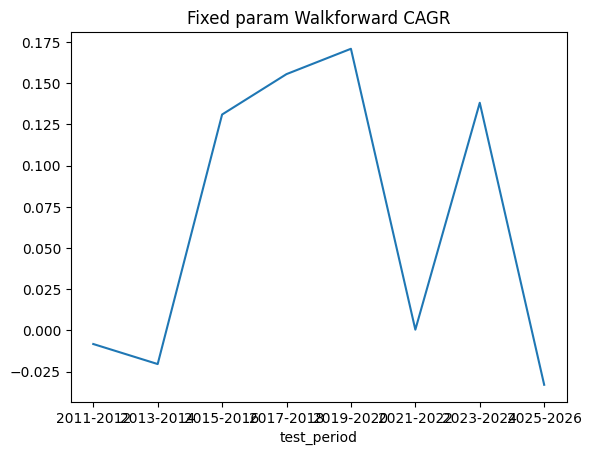

In [81]:
# CAGR
wf.set_index('test_period')['cagr'].plot(title="Fixed param Walkforward CAGR")

<Axes: title={'center': 'Fixed param Walkforward Max DD'}, xlabel='test_period'>

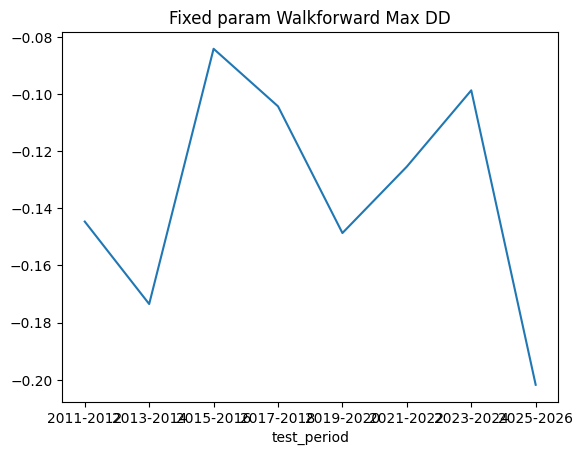

In [82]:
# Max DD
wf.set_index('test_period')['max_dd'].plot(title="Fixed param Walkforward Max DD")

In [83]:
# ROLLING WALKFORWARD OPTIMIZATION

def walkforward_optimized(df, params, train_years=6, test_years=2):

    df = df.copy()
    df["year"] = df.index.year
    years = sorted(df["year"].unique())

    results = []
    start_idx = 0

    while True:
        train_start = years[start_idx]
        train_end = train_start + train_years - 1
        test_end = train_end + test_years

        if test_end > years[-1]:
            break

        # --- slice data ---
        train_df = df[(df["year"] >= train_start) & (df["year"] <= train_end)].copy()
        test_df  = df[(df["year"] > train_end) & (df["year"] <= test_end)].copy()

        # --- OPTIMIZATION (train only) ---
        best_score = -1e9
        best_params = None
        best_train_res = None

        for breakout, atr in params:
            train_res = run_backtest(train_df.copy(), breakout, atr)

            score = score_fn(train_res)

            if score > best_score:
                best_score = score
                best_params = (breakout, atr)
                best_train_res = train_res

        # --- TEST (OOS) ---
        test_res = run_backtest(test_df.copy(), best_params[0], best_params[1])

        results.append({
            "train_period": f"{train_start}-{train_end}",
            "test_period": f"{train_end+1}-{test_end}",

            "breakout": best_params[0],
            "atr": round(best_params[1], 1),

            "train_cagr": best_train_res["cagr"],
            "train_sharpe": best_train_res["sharpe"],
            "train_max_dd": best_train_res["max_dd"],
            "train_win_rate": best_train_res["win_rate"],

            "test_cagr": test_res["cagr"],
            "test_sharpe": test_res["sharpe"],
            "test_max_dd": test_res["max_dd"],

            "test_win_rate": test_res["win_rate"],

            "test_trades": len(test_res["trades"]),
        })

        start_idx += test_years  # roll forward

    return pd.DataFrame(results)

In [89]:
wf_opt = walkforward_optimized(df, params)

wf_opt

,train_period,test_period,breakout,atr,train_cagr,train_sharpe,train_max_dd,train_win_rate,test_cagr,test_sharpe,test_max_dd,test_win_rate,test_trades
0,2005-2010,2011-2012,18,3.5,0.137191,0.635922,-0.237610,0.388889,-0.008272,-0.018688,-0.144638,0.250000,4
1,2007-2012,2013-2014,18,3.5,0.076102,0.443403,-0.244366,0.388889,-0.009801,-0.034904,-0.155530,0.200000,5
2,2009-2014,2015-2016,22,4.0,0.087971,0.608479,-0.170758,0.642857,0.105259,0.944781,-0.094501,1.000000,3
3,2011-2016,2017-2018,25,4.0,0.134512,0.877557,-0.151416,0.800000,0.108134,0.921835,-0.117046,1.000000,2
4,2013-2018,2019-2020,22,3.5,0.143581,1.009117,-0.161930,0.642857,0.157181,1.053098,-0.168300,0.666667,3
5,2015-2020,2021-2022,25,3.5,0.183447,1.254843,-0.168300,0.750000,-0.004950,0.003238,-0.124921,0.333333,3
6,2017-2022,2023-2024,25,3.5,0.095064,0.727978,-0.292038,0.461538,0.138050,1.132400,-0.098691,0.500000,2
7,2019-2024,2025-2026,20,3.5,0.110977,0.744845,-0.282310,0.357143,-0.028934,-0.155768,-0.201776,0.000000,2


In [90]:
wf_opt[['breakout','atr']].value_counts()

breakout  atr
18        3.5    2
25        3.5    2
20        3.5    1
22        3.5    1
          4.0    1
25        4.0    1
Name: count, dtype: int64

In [86]:
# Stability checks

wf_opt[['breakout','atr']].value_counts(normalize=True)

# consistency

(wf_opt['test_cagr'] > 0).mean()

np.float64(0.5)

In [87]:
# Clustering of Losses in Rolling wfo

window = 3  # rolling window of 3 periods

loss_density = (wf_opt['test_cagr'] < 0).rolling(window).mean()

print("Max loss clustering (3-period window):", loss_density.max())

Max loss clustering (3-period window): 0.6666666666666666


In [75]:
print("Avg CAGR:", wf_opt['test_cagr'].mean())
print("Median CAGR:", wf_opt['test_cagr'].median())
print("Worst CAGR:", wf_opt['test_cagr'].min())

#print("Avg Sharpe:", wf_opt['test_sharpe'].mean())
print("Worst DD:", wf_opt['test_max_dd'].min())
print("CAGR:", wf_opt['test_cagr'].max())
print("Win % (CAGR > 0):", (wf_opt['test_cagr'] > 0).mean())  #PERIOD WIN PERCENTAGE
print("Avg Trade Win Rate:", wf_opt['test_win_rate'].mean())  #WIN RATE (Trade-level)

Avg CAGR: 0.05657554567884565
Median CAGR: 0.05015464192446062
Worst CAGR: -0.032997200152525163
Worst DD: -0.2017755110887094
CAGR: 0.15718145665059002
Win % (CAGR > 0): 0.5
Avg Trade Win Rate: 0.49375


<Axes: title={'center': 'Rolling WFO CAGR'}, xlabel='test_period'>

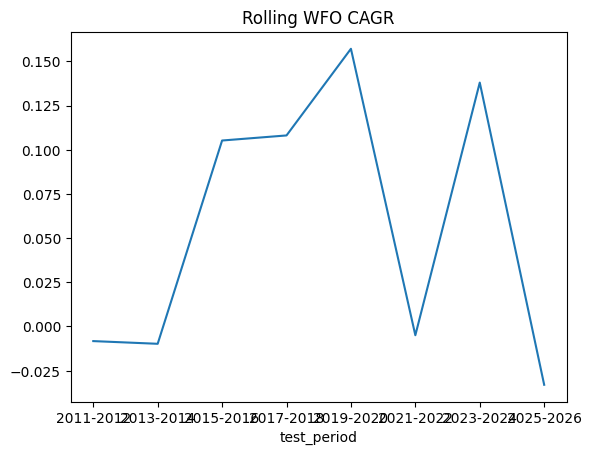

In [76]:
# CAGR
wf_opt.set_index('test_period')['test_cagr'].plot(title="Rolling WFO CAGR")

<Axes: title={'center': 'Rolling WFO Max DD'}, xlabel='test_period'>

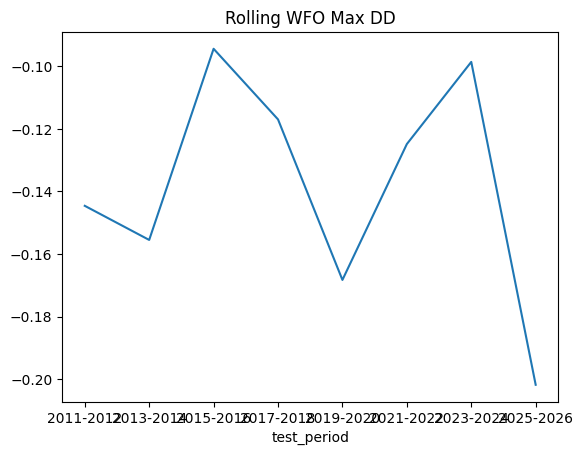

In [77]:
# Max DD
wf_opt.set_index('test_period')['test_max_dd'].plot(title="Rolling WFO Max DD")

<Axes: title={'center': 'Loss periods (1 = loss, 0 = gain)'}>

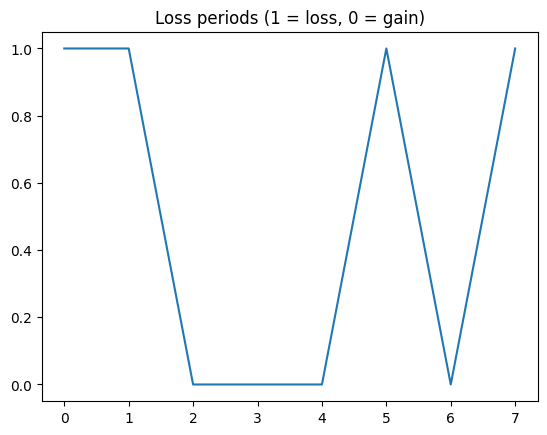

In [78]:
#CLUSTERING OF LOSSES in Rolling wfo- Visual Check
(wf_opt['test_cagr'] < 0).astype(int).plot(title="Loss periods (1 = loss, 0 = gain)")

In [79]:
#Consecutive negative periods check for fixed param and rolling param wf respectively

def consistency_check(series):

    neg = (series < 0).astype(int)

    streaks = neg.groupby((neg != neg.shift()).cumsum()).cumsum()

    

    return {

        "max_consecutive_losses": int(streaks.max()),

        "loss_cluster_3": float(neg.rolling(3).mean().max())

    }

print("Rolling:", consistency_check(wf_opt['test_cagr']))

print("Fixed:", consistency_check(wf['cagr']))

Rolling: {'max_consecutive_losses': 2, 'loss_cluster_3': 0.6666666666666666}
Fixed: {'max_consecutive_losses': 2, 'loss_cluster_3': 0.6666666666666666}


In [23]:
# Did Parameter Sensitivty Analysis; Breakout 20 & multiplier 3.5 came out on top ✅


In [ ]:
# Equity curve and Trade distribuition

equity.plot()
plt.hist(trade_returns, bins=20)



    #Diagnostic Checks:
    
    print(len(trades))
    print(trades[:5])
    if len(trades) > 0:
        print(sorted(trade_returns)[-5:])
    
    #Contribution Concentration
    if len(trades) > 0:
        total = trade_returns.sum()
        top5 = sorted(trade_returns)[-5:]
        print(sum(top5) / total)
    
    
    #Remove Top 3 trades test
    
    filtered = np.sort(trade_returns)[:-3]  # remove top 3
    print(filtered.mean())
    
    
    # Trade distribution shape
    print(np.percentile(trade_returns, [10, 25, 50, 75, 90]))
    
    
    # Equity smoothness 
    print((returns > 0).mean())
